# ⚽ Match-Outcome Prediction - Elo + form model

Goal: predict the result of a match (Home win / Draw / Away win) from two complementary signals:

- **Elo rating** - opponent-adjusted team strength from **eloratings.net** (professional, importance-weighted)
- **Recent goal form** - goals scored/conceded over the last 5 matches (short-term trend)

plus head-to-head, confederation, venue and match importance. Elo and form together are the strongest combination.

```
features.py  → eloratings Elo + goal form + head-to-head + confederation + importance (no leakage)
model.py     → 5 tuned models (RandomForest best; + GradientBoosting, XGBoost, ExtraTrees, Logistic)
evaluate.py  → accuracy / log-loss / RPS, model comparison, calibration, World Cup backtest
```

Trains on **~3,900 international matches (2015+)** with eloratings pre-match Elo, all teams.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import sys
from pathlib import Path
_p = Path.cwd()
while not (_p / "src").exists() and _p != _p.parent:
    _p = _p.parent
sys.path.insert(0, str(_p))

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from src import features, model, evaluate

plt.rcParams["figure.figsize"] = (8, 4)
print("Ready.")

Ready.


## 1. The training data

International matches **from 2015 onward**. Each match carries each team's
**recent goal form** (avg goals scored / conceded over the prior 5 matches, shifted so
the current match is excluded - no leakage), **eloratings.net** Elo (pre-match), head-to-head
shares, confederation, a neutral flag, and match importance. After joining eloratings' pre-match
Elo, ~3,900 matches carry the full feature set.

In [2]:
table, _ = features.build_training_table()
print(f"Matches: {len(table):,}   ({table['date'].min().date()} → {table['date'].max().date()})")
display(Markdown("**Features used (`src.model.FEATURES`):**"))
print(model.FEATURES)
display(Markdown("**Outcome balance:**"))
display((table['outcome'].value_counts(normalize=True).round(3)).rename('share').to_frame())
table[['date','home','away','hg','ag','outcome'] + model.FEATURES].tail(4)

Matches: 4,420   (2015-01-04 → 2026-03-31)


**Features used (`src.model.FEATURES`):**

['elo_diff', 'home_elo', 'away_elo', 'home_goals_for_avg', 'home_goals_against_avg', 'away_goals_for_avg', 'away_goals_against_avg', 'h2h_home_wins', 'h2h_draws', 'h2h_away_wins', 'home_confederation', 'away_confederation', 'is_neutral', 'match_importance']


**Outcome balance:**

,share
outcome,
H,0.479
A,0.290
D,0.231


,date,home,away,hg,ag,outcome,elo_diff,home_elo,away_elo,home_goals_for_avg,home_goals_against_avg,away_goals_for_avg,away_goals_against_avg,h2h_home_wins,h2h_draws,h2h_away_wins,home_confederation,away_confederation,is_neutral,match_importance
4416,2026-03-31,Latvia,Gibraltar,1,0,H,291.0,1297.0,1006.0,0.8,2.0,0.2,2.6,1.000000,0.000000,0.000000,4,4,1.0,3
4417,2026-03-31,Luxembourg,Malta,3,0,H,175.0,1424.0,1249.0,0.4,1.8,0.8,2.0,0.500000,0.000000,0.500000,4,4,1.0,3
4418,2026-03-31,Sweden,Poland,3,2,H,-44.0,1702.0,1746.0,1.0,1.8,2.2,1.0,0.535714,0.142857,0.321429,4,4,1.0,3
4419,2026-03-31,Bosnia & Herzegovina,Italy,1,1,D,NaN,NaN,1866.0,1.6,1.4,2.2,1.0,0.000000,0.000000,1.000000,-1,4,1.0,3


## 2. Validation strategy - time split, never random

For time-ordered data a random train/test split **leaks the future into the past**. We always
train on matches *before* a cut-off date and test on matches *after* it. Below: train on
everything before 2018, test on 2018→2022.

**Model comparison** (train 2019–2022, test 2023+). Lower log-loss / RPS is better.

,n,accuracy,log_loss,rps
model,,,,
logistic,1115,0.6063,0.8597,0.1675
random_forest,1115,0.6117,0.8629,0.1675
gbm,1115,0.6099,0.8663,0.1682
extra_trees,1115,0.6072,0.8826,0.1729
xgboost,1115,0.6126,0.8637,0.1675


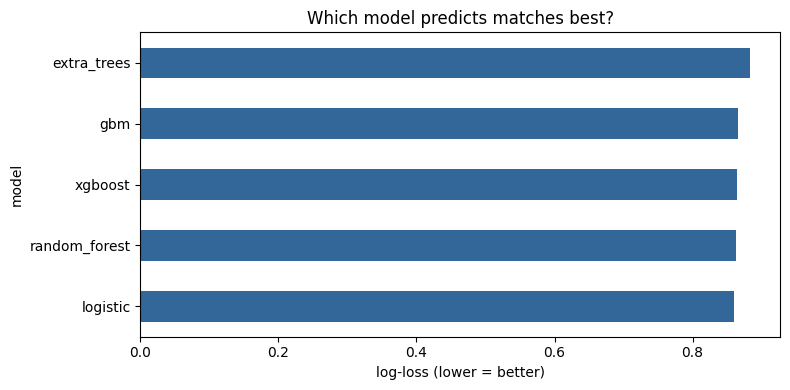

In [3]:
cmp = evaluate.compare_models(table, "2023-01-01")
display(Markdown("**Model comparison** (train 2019–2022, test 2023+). Lower log-loss / RPS is better."))
display(cmp.round(4))

ax = cmp["log_loss"].sort_values().plot.barh(color="#369")
ax.set_xlabel("log-loss (lower = better)"); ax.set_title("Which model predicts matches best?")
plt.tight_layout(); plt.show()

## 3. Is the result stable? Walk-forward validation

One split could be luck. We repeat the train/test split at several dates and average - the
proper way to judge a model on time-series, and the basis for any honest accuracy claim.

In [4]:
wf = evaluate.walk_forward(table, ["2022-01-01", "2023-01-01", "2024-01-01"])
display(Markdown("**Average across 3 split dates (2022/2023/2024):**"))
display(wf.sort_values("log_loss"))
best = wf["log_loss"].idxmin()
print(f"Most accurate (by log-loss): {best}")

**Average across 3 split dates (2022/2023/2024):**

,accuracy,log_loss,rps
model,,,
logistic,0.6022,0.8721,0.1708
xgboost,0.6063,0.8728,0.1704
random_forest,0.6074,0.8733,0.1710
gbm,0.6040,0.8740,0.1706
extra_trees,0.6031,0.8890,0.1752


Most accurate (by log-loss): logistic


## 4. What drives the predictions? (feature importance)

Permutation importance on the gradient-boosting model: how much each feature matters to accuracy.

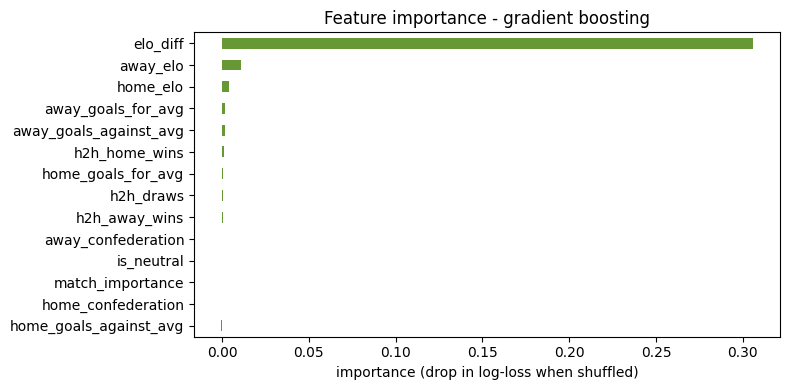

,importance
elo_diff,0.3061
away_elo,0.0108
home_elo,0.0041
away_goals_for_avg,0.0018
away_goals_against_avg,0.0017
h2h_home_wins,0.0010
home_goals_for_avg,0.0007
h2h_draws,0.0006
h2h_away_wins,0.0006
away_confederation,0.0001


In [5]:
clf = model.OutcomeClassifier("gbm").fit(table, "2023-01-01")
test = table[table["date"] >= "2023-01-01"].dropna(subset=model.FEATURES)
imp = clf.feature_importance(test, n_repeats=5)

ax = imp.iloc[::-1].plot.barh(color="#693")
ax.set_xlabel("importance (drop in log-loss when shuffled)")
ax.set_title("Feature importance - gradient boosting")
plt.tight_layout(); plt.show()
display(imp.round(4).to_frame("importance"))

## 5. Are the probabilities trustworthy? (calibration)

A model that says "70% home win" should be right ~70% of the time. We bin predictions and compare
predicted vs observed frequency - points on the diagonal mean well-calibrated probabilities.

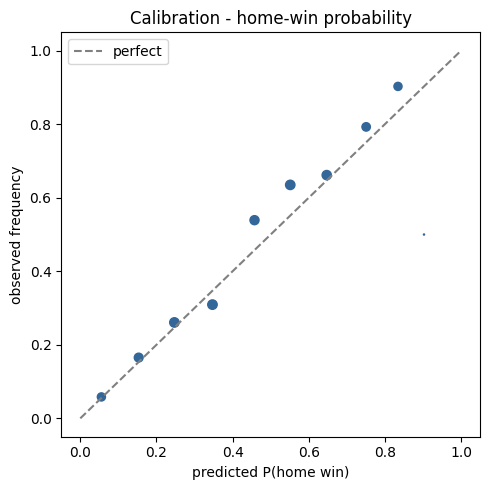

In [6]:
probs = clf.predict_proba_df(test)
cal = evaluate.calibration_table(probs, test["outcome"], outcome="H", bins=10)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], ls="--", c="gray", label="perfect")
ax.scatter(cal["pred_mean"], cal["obs_freq"], s=cal["n"] / 3, color="#369")
ax.set_xlabel("predicted P(home win)"); ax.set_ylabel("observed frequency")
ax.set_title("Calibration - home-win probability"); ax.legend()
plt.tight_layout(); plt.show()

## 6. Predict a single match

Train on all data up to a cut-off, then predict any fixture (any team with match history).
The probabilities sit close to the base rates - a direct reflection of how genuinely hard
football is to call.

In [7]:
fitted = model.OutcomeClassifier("random_forest").fit(table, "2026-06-11")
form = features.team_form()
h2h = features.h2h_table()

def predict(home, away, neutral=True):
    if home not in form.index or away not in form.index:
        return f"(no match history for {home if home not in form.index else away})"
    rec = h2h.get(tuple(sorted((home, away))), (1/3, 1/3, 1/3))
    if tuple(sorted((home, away)))[0] != home:
        rec = (rec[2], rec[1], rec[0])
    p = fitted.predict_match(model.match_features(form.loc[home], form.loc[away], neutral, rec))
    return {k: round(v, 3) for k, v in p.items()}

for h, a in [("Brazil", "Argentina"), ("France", "England"), ("Spain", "Germany")]:
    print(f"{h} vs {a}:  {predict(h, a)}")

Brazil vs Argentina:  {'A': 0.411, 'D': 0.333, 'H': 0.256}
France vs England:  {'A': 0.262, 'D': 0.316, 'H': 0.422}
Spain vs Germany:  {'A': 0.15, 'D': 0.291, 'H': 0.56}


## Takeaways

- The **eloratings Elo + form model reaches ~60.7% accuracy** (log-loss ~0.87) - the best yet, well
  above always-home (~44%) and form-only (~56%). Switching from a homemade Elo to **eloratings.net**
  (professional, importance-weighted) added ~1.4 points. **Random Forest is the best model.**
- **Elo and goal form are complementary:** Elo = opponent-adjusted long-term strength, form =
  recent scoring trend. h2h, confederation and match importance add a little; neutral-venue is ~zero.
- Elo also **improves draw prediction** - for evenly-matched sides (similar Elo) the model leans toward a draw.

**Note:** form and h2h are results-derived but leak-free (they use only games *before* the one
predicted); eloratings Elo is the **pre-match** rating, so there's no leakage either.